In [1]:
import zipfile
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

paths = ["../data/BALBc_no1.zip",
        "../data/BALBc_no2.zip",
        "../data/BALBc_no3.zip"]

all_data : dict[list[pd.DataFrame]] = {}

for path in paths:

    dataFrames : list[pd.DataFrame] = []

    with zipfile.ZipFile(path) as z:
        print("File list: ", z.namelist())

        for name in z.namelist():
            if name.endswith(".csv"):

                with z.open(name) as f:
                    df = pd.read_csv(f, sep=";")

                dataFrames.append(df)
    
    all_data[z.namelist()[0].rstrip("/")] = dataFrames
    print(f"Added {path}...")


File list:  ['BALBc_no1/', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_edges_processed.csv', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_nodes_processed.csv', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_atlas_processed.csv']
Added ../data/BALBc_no1.zip...
File list:  ['BALBc_no2/', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_edges_processed.csv', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_nodes_processed.csv', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2

In [3]:
print("All raw data size: ", len(all_data))
for i in all_data:
    print(i, "size:", len(all_data[i]))

All raw data size:  3
BALBc_no1 size: 3
BALBc_no2 size: 3
BALBc_no3 size: 3


In [4]:
for i in all_data:
    print(f"========={i} ==========")
    for j in all_data[i]:
        print("------dataFrame------")
        print(j.info(), "\n")

=========BALBc_no1 ==========
------dataFrame------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5345897 entries, 0 to 5345896
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   node1id                int64  
 2   node2id                int64  
 3   length                 float64
 4   distance               float64
 5   curveness              float64
 6   volume                 int64  
 7   avgCrossSection        float64
 8   minRadiusAvg           float64
 9   minRadiusStd           float64
 10  avgRadiusAvg           float64
 11  avgRadiusStd           float64
 12  maxRadiusAvg           float64
 13  maxRadiusStd           float64
 14  roundnessAvg           float64
 15  roundnessStd           float64
 16  node1_degree           int64  
 17  node2_degree           int64  
 18  num_voxels             int64  
 19  hasNodeAtSampleBorder  int64  
dtypes: float64(12), int64(8)
memory usage:

In [5]:
for i in all_data:
    print(f"========={i} ==========")
    for j in all_data[i]:
        print("------dataFrame------")
        print(j.head(15), "\n")

=========BALBc_no1 ==========
------dataFrame------
    id  node1id  node2id     length   distance  curveness  volume  \
0    0        0   278560  182.46400  167.94600    1.08644    9164   
1    1        1        3    9.98625    6.70820    1.48866      97   
2    2        2   249900    2.48805    2.44949    1.01574     134   
3    3        4   249907   24.57610   20.87260    1.17743    1201   
4    4        5   249901    3.66110    3.60555    1.01541     330   
5    5        6   249900   25.39440   19.31320    1.31487    1113   
6    6        7   249920   41.01840   38.37320    1.06894    2857   
7    7        8   249902    6.00833    5.61249    1.07053     300   
8    8        9   249948   13.90060   13.63820    1.01924      56   
9    9       10   249947   17.44840   10.24700    1.70279     111   
10  10       11   249949   87.94370   85.18410    1.03240     894   
11  11       12   249944   57.76390   54.75400    1.05497     736   
12  12       13   249999   19.65050   12.68860    1

In [6]:
BALBc_1_1 : pd.DataFrame = all_data["BALBc_no1"][0]
BALBc_1_2 : pd.DataFrame = all_data["BALBc_no1"][1]
BALBc_1_3 : pd.DataFrame = all_data["BALBc_no1"][2]
BALBc_2_1 : pd.DataFrame = all_data["BALBc_no2"][0]
BALBc_2_2 : pd.DataFrame = all_data["BALBc_no2"][1]
BALBc_2_3 : pd.DataFrame = all_data["BALBc_no2"][2]
BALBc_3_1 : pd.DataFrame = all_data["BALBc_no3"][0]
BALBc_3_2 : pd.DataFrame = all_data["BALBc_no3"][1]
BALBc_3_3 : pd.DataFrame = all_data["BALBc_no3"][2]

print("BALBc_1:", BALBc_1_1.columns)
print("BALBc_1:", BALBc_1_2.columns)
print("BALBc_1:", BALBc_1_3.columns)
print("BALBc_2:", BALBc_2_1.columns)
print("BALBc_2:", BALBc_2_2.columns)
print("BALBc_2:", BALBc_2_3.columns)
print("BALBc_3:", BALBc_3_1.columns)
print("BALBc_3:", BALBc_3_2.columns)
print("BALBc_3:", BALBc_3_3.columns)

BALBc_1: Index(['id', 'node1id', 'node2id', 'length', 'distance', 'curveness', 'volume',
       'avgCrossSection', 'minRadiusAvg', 'minRadiusStd', 'avgRadiusAvg',
       'avgRadiusStd', 'maxRadiusAvg', 'maxRadiusStd', 'roundnessAvg',
       'roundnessStd', 'node1_degree', 'node2_degree', 'num_voxels',
       'hasNodeAtSampleBorder'],
      dtype='object')
BALBc_1: Index(['id', 'pos_x', 'pos_y', 'pos_z', 'degree', 'isAtSampleBorder'], dtype='object')
BALBc_1: Index(['Region_Acronym_ACA', 'Region_Acronym_AI', 'Region_Acronym_AOB',
       'Region_Acronym_AOBgr', 'Region_Acronym_AON', 'Region_Acronym_AUD',
       'Region_Acronym_BLA', 'Region_Acronym_BMA', 'Region_Acronym_BS',
       'Region_Acronym_CA1sp', 'Region_Acronym_CB', 'Region_Acronym_CBXmo',
       'Region_Acronym_CNU', 'Region_Acronym_COA', 'Region_Acronym_CTXsp',
       'Region_Acronym_CUL4', 'Region_Acronym_DORpm', 'Region_Acronym_DORsm',
       'Region_Acronym_DP', 'Region_Acronym_ECT', 'Region_Acronym_EP',
       'Region_Acr

## **BALBc 1**

### 1. Describe

In [7]:
BALBc_1_1.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06
mean,2.672948e+06,1.806530e+06,1.896018e+06,1.279869e+01,1.145000e+01,1.088693e+00,3.899617e+02,2.824333e+01,2.476473e+00,3.649567e-01,3.508176e+00,4.196538e-01,4.739847e+00,7.138724e-01,5.314004e-01,9.184909e-02,3.133139e+00,3.268482e+00,8.902883e+00,1.496475e-06
std,1.543228e+06,9.993347e+05,9.488214e+05,9.064357e+00,7.218522e+00,1.636323e-01,5.647224e+02,2.050822e+01,1.121808e+00,3.353218e-01,1.217720e+00,3.752447e-01,1.600603e+00,6.338605e-01,1.203201e-01,8.568570e-02,7.247576e-01,5.962765e-01,7.725755e+00,1.223304e-03
min,0.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00,1.776800e+00,1.862633e-01,1.000000e+00,2.981420e-01,5.000000e-01,0.000000e+00,7.947460e-01,0.000000e+00,9.174240e-01,0.000000e+00,4.718740e-02,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.336474e+06,9.458470e+05,1.074399e+06,6.686590e+00,6.442050e+00,1.018540e+00,1.340000e+02,1.668850e+01,1.788670e+00,1.853900e-01,2.762130e+00,1.935620e-01,3.750970e+00,3.233260e-01,4.569560e-01,5.393870e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.000000e+00
50%,2.672948e+06,1.806942e+06,1.895007e+06,1.039630e+01,9.780900e+00,1.042930e+00,2.550000e+02,2.404800e+01,2.322540e+00,3.146660e-01,3.358020e+00,3.405610e-01,4.494290e+00,5.631100e-01,5.333080e-01,8.372510e-02,3.000000e+00,3.000000e+00,7.000000e+00,0.000000e+00
75%,4.009422e+06,2.669647e+06,2.717500e+06,1.606630e+01,1.444540e+01,1.093960e+00,4.660000e+02,3.408110e+01,2.926540e+00,4.637680e-01,4.015180e+00,5.482020e-01,5.381560e+00,9.289000e-01,6.039490e-01,1.166110e-01,3.000000e+00,3.000000e+00,1.200000e+01,0.000000e+00
max,5.345896e+06,3.538492e+06,3.538494e+06,3.228130e+02,3.006980e+02,2.743440e+01,1.194590e+05,1.587499e+03,3.865820e+01,1.249650e+01,3.865820e+01,1.199950e+01,4.412900e+01,2.364330e+01,1.997629e+00,1.000000e+00,1.400000e+01,1.400000e+01,2.560000e+02,1.000000e+00


In [8]:
BALBc_1_2.describe()

,id,pos_x,pos_y,pos_z,degree,isAtSampleBorder
count,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06
mean,1.769247e+06,1.563105e+03,2.915366e+03,9.119264e+02,3.021565e+00,2.543454e-06
std,1.021476e+06,6.370472e+02,8.961347e+02,4.022904e+02,7.359357e-01,1.594819e-03
min,0.000000e+00,1.780000e+02,8.080000e+02,0.000000e+00,1.000000e+00,0.000000e+00
25%,8.846235e+05,1.054500e+03,2.201330e+03,5.870000e+02,3.000000e+00,0.000000e+00
50%,1.769247e+06,1.548670e+03,2.905000e+03,9.141670e+02,3.000000e+00,0.000000e+00
75%,2.653870e+06,2.059500e+03,3.692000e+03,1.224000e+03,3.000000e+00,0.000000e+00
max,3.538494e+06,3.096000e+03,4.719000e+03,1.866330e+03,1.400000e+01,1.000000e+00


In [9]:
BALBc_1_3.describe()

,Region_Acronym_ACA,Region_Acronym_AI,Region_Acronym_AOB,Region_Acronym_AOBgr,Region_Acronym_AON,Region_Acronym_AUD,Region_Acronym_BLA,Region_Acronym_BMA,Region_Acronym_BS,Region_Acronym_CA1sp,...,Region_Acronym_TEa,Region_Acronym_TR,Region_Acronym_TT,Region_Acronym_VIS,Region_Acronym_VISC,Region_Acronym_VS,Region_Acronym_bgr,Region_Acronym_fiber tracts,Region_Acronym_root,Region_Acronym_sAMY
count,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,...,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06
mean,1.072179e-02,1.464295e-02,8.396225e-04,9.447519e-04,9.210413e-03,1.502447e-02,2.648584e-03,2.122371e-03,1.475769e-03,1.674158e-03,...,5.892901e-03,1.876221e-03,2.538367e-03,2.778526e-02,3.693943e-03,7.905903e-03,7.879141e-02,4.937042e-02,4.598565e-03,6.167876e-03
std,1.029895e-01,1.201188e-01,2.896408e-02,3.072230e-02,9.552792e-02,1.216501e-01,5.139620e-02,4.602029e-02,3.838738e-02,4.088222e-02,...,7.653872e-02,4.327472e-02,5.031823e-02,1.643571e-01,6.066547e-02,8.856299e-02,2.694130e-01,2.166403e-01,6.765663e-02,7.829327e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [17]:
BALBc_2_1.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5.193775e+06,5193775.0
mean,2.596887e+06,1.758284e+06,1.854709e+06,1.330354e+01,1.186372e+01,1.090568e+00,4.161564e+02,2.904513e+01,2.539425e+00,3.782914e-01,3.531864e+00,4.298721e-01,4.704290e+00,7.093277e-01,5.488621e-01,9.334411e-02,3.119719e+00,3.255478e+00,9.313023e+00,0.0
std,1.499314e+06,9.736674e+05,9.231271e+05,9.584599e+00,7.586558e+00,1.695893e-01,6.506553e+02,2.193949e+01,1.171613e+00,3.561741e-01,1.280627e+00,3.952177e-01,1.669683e+00,6.559688e-01,1.209115e-01,9.589547e-02,7.195793e-01,5.841781e-01,8.155913e+00,0.0
min,0.000000e+00,0.000000e+00,2.514960e+05,2.000000e+00,6.863040e-01,2.548925e-01,1.000000e+00,3.218820e-01,5.000000e-01,0.000000e+00,8.327210e-01,0.000000e+00,1.000000e+00,0.000000e+00,3.395580e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.0
25%,1.298444e+06,9.195420e+05,1.055824e+06,6.838300e+00,6.599640e+00,1.018650e+00,1.400000e+02,1.703460e+01,1.832500e+00,1.893590e-01,2.762110e+00,1.925400e-01,3.701530e+00,3.129460e-01,4.776600e-01,5.370750e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.0
50%,2.596887e+06,1.757226e+06,1.854295e+06,1.073080e+01,1.006130e+01,1.043140e+00,2.680000e+02,2.438000e+01,2.373720e+00,3.178680e-01,3.347460e+00,3.395700e-01,4.403540e+00,5.414050e-01,5.521740e-01,8.241000e-02,3.000000e+00,3.000000e+00,7.000000e+00,0.0
75%,3.895330e+06,2.598432e+06,2.654318e+06,1.676160e+01,1.503330e+01,1.094980e+00,4.930000e+02,3.443080e+01,2.968350e+00,4.711825e-01,4.012670e+00,5.553150e-01,5.301350e+00,9.095240e-01,6.194740e-01,1.154350e-01,3.000000e+00,3.000000e+00,1.200000e+01,0.0
max,5.193774e+06,3.451304e+06,3.451305e+06,4.015050e+02,3.437770e+02,2.283034e+01,2.574900e+05,1.770490e+03,4.974400e+01,1.498000e+01,4.974400e+01,1.479600e+01,4.974400e+01,1.871500e+01,2.640367e+00,1.000000e+00,1.600000e+01,1.600000e+01,3.500000e+02,0.0


In [18]:
BALBc_3_1.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4.097953e+06,4097953.0
mean,2.048976e+06,1.476797e+06,1.607437e+06,1.415666e+01,1.246498e+01,1.103584e+00,4.438503e+02,2.918773e+01,2.480379e+00,3.947155e-01,3.502068e+00,4.709190e-01,4.716042e+00,7.889425e-01,5.364134e-01,9.727774e-02,3.012682e+00,3.232435e+00,1.008948e+01,0.0
std,1.182977e+06,7.964234e+05,7.177206e+05,1.029311e+01,8.035616e+00,1.973674e-01,6.779894e+02,2.353943e+01,1.233652e+00,3.693229e-01,1.369195e+00,4.277750e-01,1.801816e+00,7.253706e-01,1.206762e-01,9.276235e-02,8.097932e-01,5.623826e-01,8.791679e+00,0.0
min,0.000000e+00,0.000000e+00,3.631300e+05,2.000000e+00,2.000000e+00,2.512225e-01,2.000000e+00,3.523570e-01,5.000000e-01,0.000000e+00,7.814800e-01,0.000000e+00,9.579350e-01,0.000000e+00,4.065430e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.0
25%,1.024488e+06,7.999770e+05,9.856320e+05,7.162620e+00,6.879940e+00,1.020370e+00,1.430000e+02,1.623820e+01,1.739830e+00,2.014610e-01,2.659570e+00,2.118840e-01,3.597080e+00,3.444870e-01,4.636330e-01,5.730110e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.0
50%,2.048976e+06,1.481100e+06,1.606488e+06,1.139990e+01,1.061450e+01,1.047370e+00,2.760000e+02,2.368360e+01,2.257200e+00,3.335590e-01,3.277020e+00,3.734130e-01,4.372520e+00,6.005080e-01,5.384910e-01,8.762440e-02,3.000000e+00,3.000000e+00,8.000000e+00,0.0
75%,3.073464e+06,2.162977e+06,2.228889e+06,1.793590e+01,1.581930e+01,1.107380e+00,5.170000e+02,3.456400e+01,2.912120e+00,4.894040e-01,4.014400e+00,6.082920e-01,5.377770e+00,1.000000e+00,6.064600e-01,1.216940e-01,3.000000e+00,3.000000e+00,1.300000e+01,0.0
max,4.097952e+06,2.850345e+06,2.850346e+06,3.481990e+02,3.159930e+02,1.733610e+01,7.330900e+04,1.891440e+03,3.932690e+01,1.132900e+01,3.932690e+01,1.186530e+01,3.932690e+01,1.991240e+01,1.850078e+00,1.000000e+00,1.400000e+01,1.400000e+01,2.940000e+02,0.0


### 2. EDA

In [10]:
# bỏ các cột id
df_plot = BALBc_1_1.drop(columns=["id", "node1id", "node2id", "hasNodeAtSampleBorder"])

# sampling để plot nhanh
df_sample = df_plot.sample(n=100000, random_state=42)

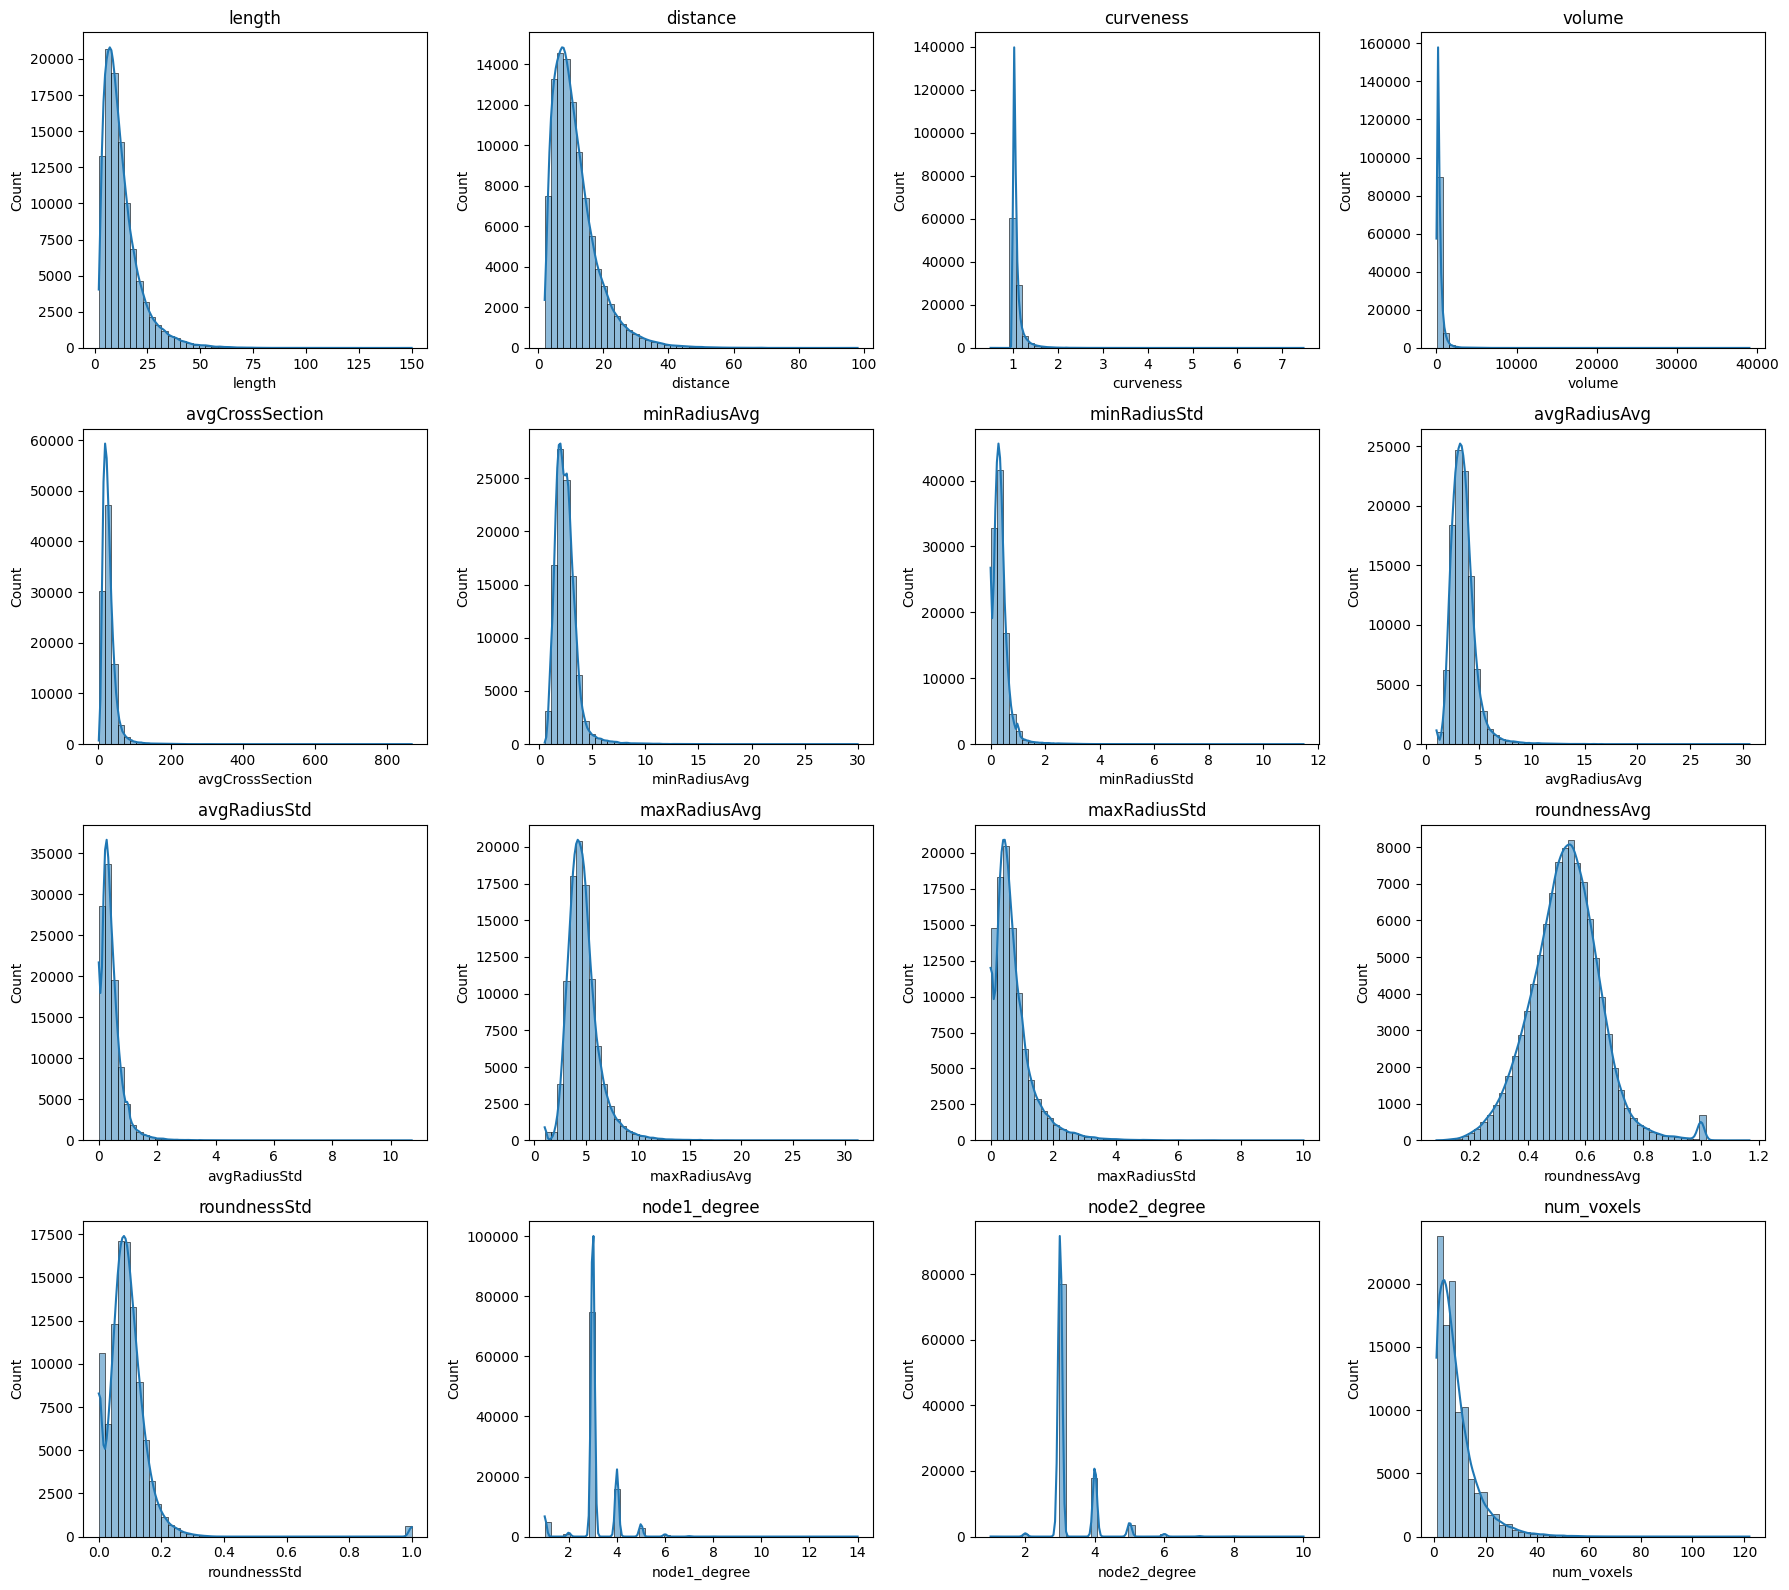

In [11]:
cols = df_sample.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sample[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

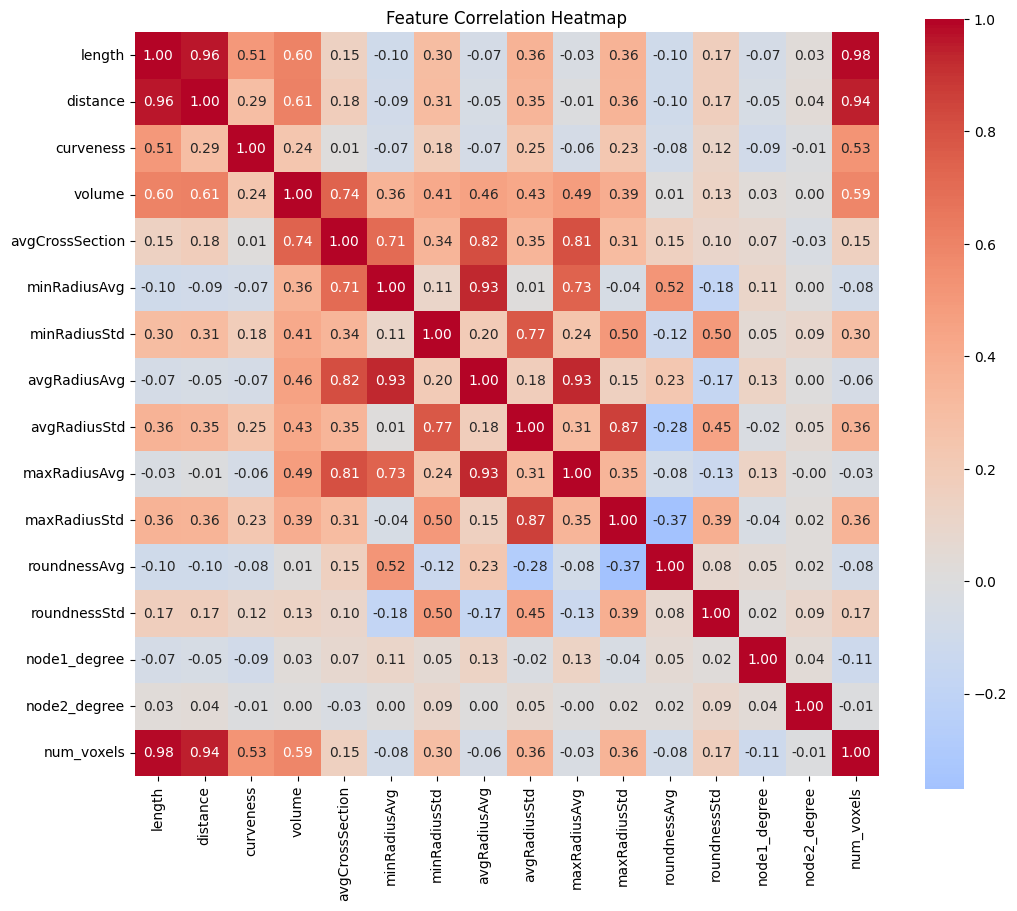

In [12]:
# tính correlation
corr = df_sample.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
# bỏ các cột id
df_plot = BALBc_1_2.drop(columns=["id", "pos_x", "pos_y", "pos_z"])

# sampling để plot nhanh
df_sample = df_plot.sample(n=100000, random_state=42)

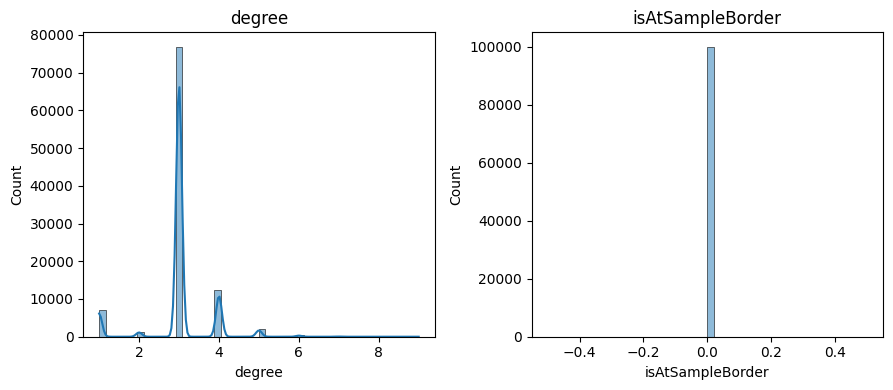

In [14]:
cols = df_sample.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sample[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### 3. Features

In [15]:
# bỏ các cột id
df_feats = BALBc_1_3

# sampling để plot nhanh
df_sam_feats = df_feats.sample(n=100000, random_state=42)

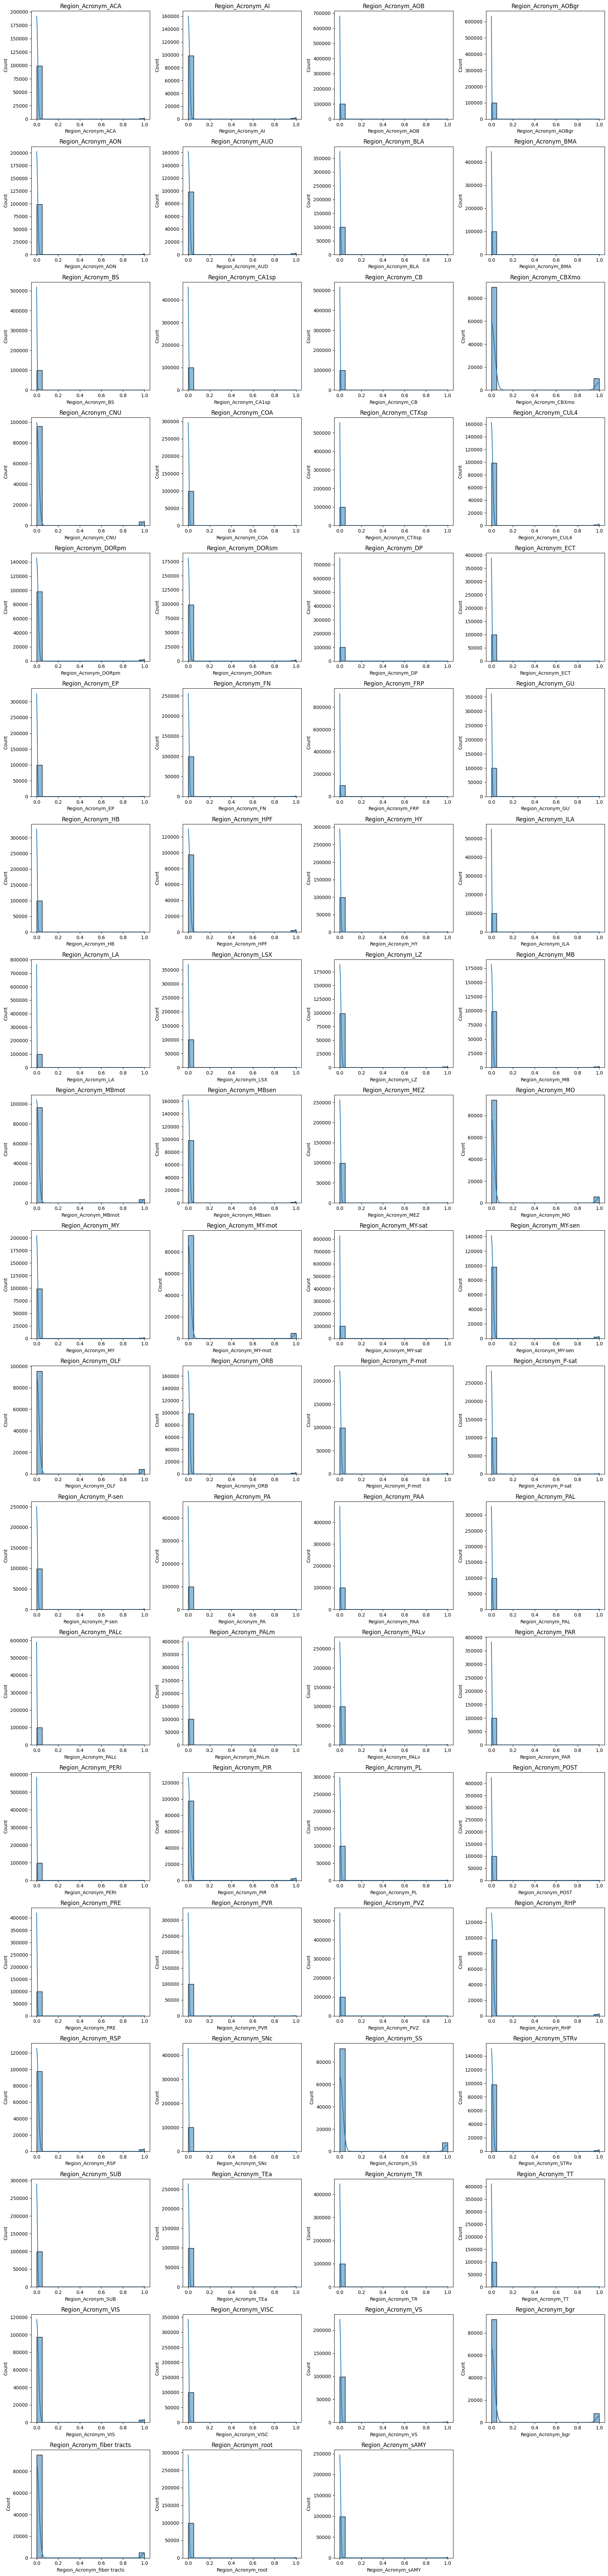

In [19]:
cols = df_sam_feats.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sam_feats[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### 4. Train - GCN

In [20]:
os.environ["PYTHONHASHSEED"] = str(42)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"


import torch
import torch_sparse

from torch_geometric.data import Data
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.loader import LinkNeighborLoader
import torch_geometric.typing

import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import random

torch_geometric.typing.WITH_PYG_LIB = False
torch_geometric.typing.WITH_TORCH_SPARSE = True
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [21]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.use_deterministic_algorithms(True)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(42)

In [22]:
nodes = BALBc_1_2
regions = BALBc_1_3

node_features = np.concatenate(
[
    nodes[["pos_x","pos_y","pos_z","degree","isAtSampleBorder"]].values,
    regions.values
],
axis=1
)

scaler = StandardScaler()

node_features = scaler.fit_transform(node_features)

x = torch.tensor(node_features, dtype=torch.float32)

In [23]:
edges = BALBc_1_1

src = edges["node1id"].values
dst = edges["node2id"].values

edge_index = torch.tensor(
    np.vstack([src,dst]),
    dtype=torch.long
)
print(edge_index.shape)

torch.Size([2, 5345897])


In [24]:
data = Data(
    x=x,
    edge_index=edge_index
)

In [25]:
""" class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=64, dropout=0.3):
        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim)

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)

        x = F.normalize(x, dim=1)

        return x """

class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=64, dropout=0.3):
        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, out_dim)

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)

        x = F.normalize(x, dim=1)
        return x

In [26]:
def decode(z, edge_index):
    src, dst = edge_index
    return (z[src] * z[dst]).sum(dim=1)


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device.type)

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

cuda
2.1.0+cu121
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [28]:

loader = LinkNeighborLoader(
    data,
    num_neighbors=[5, 3],
    batch_size=1024,          
    shuffle=False,
    edge_label_index=data.edge_index,
    neg_sampling_ratio=0.5,  
    num_workers=0,
    generator=g,          
)

set_seed(42)
model = GCN(x.shape[1]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

epoch_losses = []

for epoch in range(10):

    model.train()
    total_loss = 0.0

    for batch in loader:

        batch = batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        z = model(batch.x, batch.edge_index)
        scores = decode(z, batch.edge_label_index)

        loss = F.binary_cross_entropy_with_logits(
            scores, batch.edge_label
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()

        total_loss += loss.detach()


    epoch_loss = (total_loss / len(loader)).item()
    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:02d} | Loss = {epoch_loss:.6f}")


Epoch 01 | Loss = 0.447382


KeyboardInterrupt: 

In [ ]:
torch.save({
    "model_state": model.state_dict(),
    "in_dim": x.shape[1],
    "hidden": 128,
    "out_dim": 64
}, "model_GCN.pt")


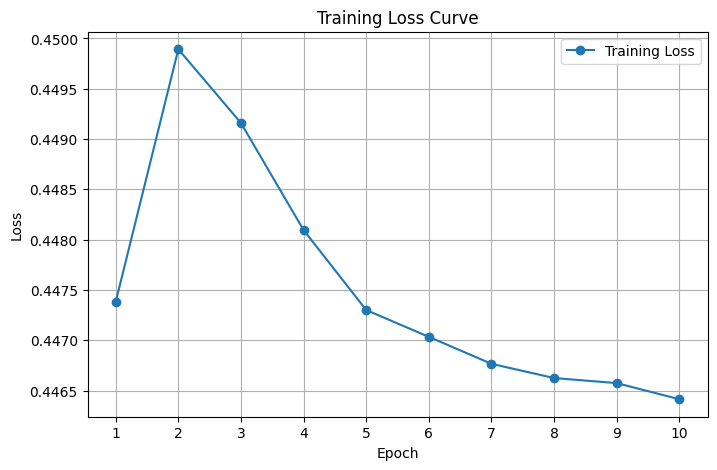

In [ ]:
plt.figure(figsize=(8, 5))

epochs = range(1, len(epoch_losses) + 1)

plt.plot(epochs, epoch_losses, marker='o', label='Training Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.xticks(epochs) 

plt.grid(True)
plt.legend()
plt.show()

In [29]:
ckpt = torch.load("model_GCN.pt", map_location=device)

model = GCN(
    in_dim=ckpt["in_dim"], 
    hidden=ckpt["hidden"], 
    out_dim=ckpt["out_dim"]
)

model.load_state_dict(ckpt["model_state"])

edges = edge_index.numpy()

deg = defaultdict(int)

for u, v in edges.T:
    deg[u] += 1
    deg[v] += 1

endpoints = [n for n, d in deg.items() if d == 1]

print("Endpoints:", len(endpoints))


Endpoints: 251793


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        out_dim = out.shape[1]
        break

z = torch.zeros((data.num_nodes, out_dim), device=device)

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        z[batch.n_id] = out

In [31]:
edges = BALBc_2_1

src = edges["node1id"].values
dst = edges["node2id"].values

edge_index2 = torch.tensor(
    np.vstack([src, dst]),
    dtype=torch.long,
    device=device
)


In [32]:

val_pos = edge_index2

val_neg = negative_sampling(
    edge_index=edge_index2,
    num_nodes=z.size(0),
    num_neg_samples=val_pos.size(1)
)

In [33]:
pos_scores = torch.sigmoid(decode(z, val_pos))
neg_scores = torch.sigmoid(decode(z, val_neg))

y_true = torch.cat([
    torch.ones_like(pos_scores),
    torch.zeros_like(neg_scores)
]).cpu().numpy()

y_score = torch.cat([
    pos_scores,
    neg_scores
]).detach().cpu().numpy()

best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.9, 100):
    y_pred = (y_score > t).astype(int)
    f1 = f1_score(y_true, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

In [34]:
y_pred = (y_score > best_t).astype(int)

f1 = f1_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print("VAL Best threshold:", best_t)
print("VAL ROC-AUC:", auc)
print("VAL F1:", f1)
print("VAL ACC:", acc)

VAL Best threshold: 0.38282828282828285
VAL ROC-AUC: 0.6233006322756088
VAL F1: 0.6668384860951593
VAL ACC: 0.5009747245500623


In [35]:
edges = BALBc_3_1

src = edges["node1id"].values
dst = edges["node2id"].values

test_index2 = torch.tensor(
    np.vstack([src,dst]),
    dtype=torch.long
)

# positive
test_pos = test_index2

# negative
test_neg = negative_sampling(
    edge_index=test_index2,
    num_nodes=z.size(0),
    num_neg_samples=test_pos.size(1)
)

# scores
pos_scores = torch.sigmoid(decode(z, test_pos))
neg_scores = torch.sigmoid(decode(z, test_neg))

# labels
y_true = torch.cat([
    torch.ones_like(pos_scores),
    torch.zeros_like(neg_scores)
]).cpu().numpy()

# predictions
y_score = torch.cat([
    pos_scores,
    neg_scores
]).detach().cpu().numpy()

# AUC

y_pred = (y_score > best_t).astype(int)

f1 = f1_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print("ROC-AUC:", auc)
print("F1:", f1)
print("Accuracy:", acc)

ROC-AUC: 0.5764469176542257
F1: 0.6667254857872801
Accuracy: 0.5008583553788928


### 5. Train node classification

In [78]:
from torch_geometric.loader import DataLoader

In [79]:
def create_edge_labels(edges: pd.DataFrame):
    """
    Tạo edge_index và edge_label cho PyG.
    """
    edge_index = torch.tensor(edges[['node1id','node2id']].values.T, dtype=torch.long)
    edge_label = torch.ones(edge_index.shape[1], dtype=torch.float)
    return edge_index, edge_label


def prepare_node_features(train_edges: pd.DataFrame, train_nodes: pd.DataFrame):
    """
    Gom trực tiếp các cột node position và minRadius từ hai dataframe
    mà không biến đổi dữ liệu, lấy minRadius từ cả node1 và node2.
    
    Args:
        train_edges: DataFrame chứa edge info, bao gồm 'node1id','node2id','minRadiusAvg'
        train_nodes: DataFrame chứa node info, bao gồm 'id','pos_x','pos_y','pos_z'
    
    Returns:
        x: tensor feature [num_nodes, 4] (pos_x, pos_y, pos_z, minRadius)
        edge_index: tensor [2, num_edges] cho PyG
        nodes_merged: DataFrame gộp thông tin node + minRadius
    """
    # --- 1️⃣ Gom minRadius từ node1 và node2 ---
    node1_radius = train_edges[['node1id','minRadiusAvg']].rename(
        columns={'node1id':'id','minRadiusAvg':'minRadius_node1'}
    )
    node2_radius = train_edges[['node2id','minRadiusAvg']].rename(
        columns={'node2id':'id','minRadiusAvg':'minRadius_node2'}
    )

    # --- 2️⃣ Merge 2 bảng lại và lấy min ---
    node_radius = pd.merge(node1_radius, node2_radius, on='id', how='outer')
    node_radius['minRadius'] = node_radius[['minRadius_node1','minRadius_node2']].min(axis=1)

    # --- 3️⃣ Merge với bảng node để có pos_x, pos_y, pos_z ---
    nodes_merged = train_nodes.merge(node_radius[['id','minRadius']], on='id', how='left')
    nodes_merged = nodes_merged.sort_values('id').reset_index(drop=True)

    # --- 4️⃣ Tạo feature tensor ---
    x = torch.tensor(nodes_merged[['pos_x','pos_y','pos_z','minRadius']].values, dtype=torch.float)

    # --- 5️⃣ Tạo edge_index ---
    edge_index = torch.tensor(train_edges[['node1id','node2id']].values.T, dtype=torch.long)

    return x, edge_index, nodes_merged

In [80]:
x, edge_index, nodes_merged = prepare_node_features(BALBc_2_1, BALBc_2_2)
nodes_merged['minRadius_um'] = nodes_merged['minRadius']

def assign_vessel_type(r):
    if r < 15:
        return 0
    elif 15 <= r <= 40:
        return 1
    else:
        return 2

nodes_merged['vessel_type'] = nodes_merged['minRadius_um'].apply(assign_vessel_type)

y = torch.tensor(nodes_merged['vessel_type'].values, dtype=torch.long)

edge_index, edge_label = create_edge_labels(BALBc_2_1)

data = Data(x=x, edge_index=edge_index, y=y, edge_label=edge_label)

loader = DataLoader([data], batch_size=1, shuffle=True)

print("Node feature tensor shape:", x.shape)
print("Edge index shape:", edge_index.shape)
print("Node label distribution:")
print(nodes_merged['vessel_type'].value_counts(normalize=True)*100)

Node feature tensor shape: torch.Size([7731117, 4])
Edge index shape: torch.Size([2, 5193775])
Node label distribution:
vessel_type
0    99.984918
1     0.015069
2     0.000013
Name: proportion, dtype: float64


In [91]:
# Chuyển tất cả lớp != 0 thành 1
nodes_merged['vessel_type_bin'] = (nodes_merged['vessel_type'] != 0).astype(int)
y = torch.tensor(nodes_merged['vessel_type_bin'].values, dtype=torch.long)

classes, counts = np.unique(y.cpu().numpy(), return_counts=True)
num_classes = 2
class_weights = torch.ones(num_classes, dtype=torch.float)
for c, cnt in zip(classes, counts):
    class_weights[c] = counts.sum() / cnt

pos_weight = torch.tensor(counts[0] / counts[1], dtype=torch.float)
print(pos_weight)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

tensor(6629.4604)


In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GCNConv
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------
# 1️⃣ Prepare node features
# ------------------------
def prepare_node_features(edges, nodes):
    nodes_merged = nodes.merge(
        edges[['node1id','minRadiusAvg']],
        left_on='id', right_on='node1id', how='left'
    ).rename(columns={'minRadiusAvg':'minRadius'})
    nodes_merged['minRadius'] = nodes_merged['minRadius'].fillna(0.0)
    nodes_merged = nodes_merged.sort_values('id').reset_index(drop=True)
    x = torch.tensor(nodes_merged[['pos_x','pos_y','pos_z','minRadius']].values, dtype=torch.float)
    return x, nodes_merged

# ------------------------
# 2️⃣ Assign binary vessel type
# ------------------------
def assign_vessel_type_bin(nodes_merged):
    nodes_merged['vessel_type_bin'] = (nodes_merged['minRadius'] >= 15).astype(int)
    y = torch.tensor(nodes_merged['vessel_type_bin'].values, dtype=torch.float).view(-1,1)
    return y, nodes_merged

# ------------------------
# 3️⃣ Create edge_index
# ------------------------
def create_edge_index(edges):
    return torch.tensor(edges[['node1id','node2id']].values.T, dtype=torch.long)

# ------------------------
# 4️⃣ Define GCN
# ------------------------
class GCN(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.fc = nn.Linear(hidden,1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return self.fc(x)

# ------------------------
# 5️⃣ Load dataset
# ------------------------
x, nodes_merged = prepare_node_features(BALBc_1_1, BALBc_1_2)
y, nodes_merged = assign_vessel_type_bin(nodes_merged)
edge_index = create_edge_index(BALBc_1_1)

data = Data(x=x, edge_index=edge_index, y=y)

# ------------------------
# 6️⃣ NeighborLoader
# ------------------------
train_loader = NeighborLoader(
    data,
    num_neighbors=[10,5],
    batch_size=8192,
    shuffle=True
)

# ------------------------
# 7️⃣ pos_weight
# ------------------------
counts = np.bincount(nodes_merged['vessel_type_bin'])
pos_weight_value = counts[0] / max(1, counts[1])
pos_weight_value = min(pos_weight_value, 50.0)
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ------------------------
# 8️⃣ Model + optimizer
# ------------------------
model = GCN(data.num_node_features, hidden=128).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

# ------------------------
# 9️⃣ Training loop
# ------------------------
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        batch_x = batch.x.to(device)
        batch_edge_index = batch.edge_index.to(device)
        batch_y = batch.y.view(-1,1).float().to(device)

        optimizer.zero_grad()
        z = model(batch_x, batch_edge_index)
        loss = criterion(z, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/num_batches:.6f}")

# ------------------------
# 🔟 Save model
# ------------------------
torch.save(model.state_dict(), "gcn_binary_vessel.pt")

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
torch.save({
    "model_state": model.state_dict(),
    "in_dim": x.shape[1],
    "hidden": 128,
    "out_dim": 64
}, "model_GCN2.pt")


In [ ]:
plt.figure(figsize=(8, 5))

epochs = range(1, len(epoch_losses) + 1)

plt.plot(epochs, epoch_losses, marker='o', color="#B81212", label='Training Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.xticks(epochs) 

plt.grid(True)
plt.legend()
plt.show()